# Esame Laboratorio di Programmazione II - 22/07/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e rinominate il file che consegnate come `matricola.ipynb` (la matricola è SMnumeri o ECnumeri).

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domande e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB: Potete usare anche più di una cella python per domanda e se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza etichette sugli assi o illeggibili sarà valutato meno bene di uno con etichette chiare.

Cercate di commmentare il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
import numpy as np

## Esercizio 1

Crea un vettore NumPy con le seguenti spese annuali per l’auto (in euro) sostenute da 7 persone:
3200, 2750, 4100, 3600, 2950, 5100, 4400

1. Calcola la spesa totale complessiva sostenuta dal gruppo.

2. Le persone con spese minori di 3000 € ottengono una detrazione fiscale del 15%. Applica la modifica al vettore.

3. Quanto ha risparmiato il gruppo dopo la detrazione fiscale?


In [7]:
spese = np.array([3200, 2750, 4100, 3600, 2950, 5100, 4400], dtype=float)

In [8]:
tot0 = sum(spese)
print(tot0)

26100.0


In [19]:
spese[spese<3000]*=(85/100)

print(spese)

[3200.    2336.055 4100.    3600.    2506.055 5100.    4400.   ]


In [20]:
tot1 = sum(spese)
print("sono stati rispatmiati {} euro".format(tot0-tot1))

sono stati rispatmiati 857.8899999999994 euro


## Esercizio 2
1. Scrivi una funzione che simula il lancio di un dado per N volte e restituisce un array con il numero di volte che è uscita ciascuna faccia (da 1 a 6).
2. Calcolare la frequenza % con la dimensione del campione (numero di lanci) 100 volte da 10 a 5000.  Ottieni così 100 array di frequenze.
3. Fai il plot dell’andamento della frequenza media delle facce 1, 3 e 6 in funzione della dimensione del campione.



In [24]:
vec_prob = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]

def lancia(N):
    res = np.random.choice([1,2,3,4,5,6], N, replace=True, p=vec_prob)
    return (res)

print(lancia(10))

[2 5 2 6 2 6 3 6 5 1]


Text(0, 0.5, 'frequenze relative')

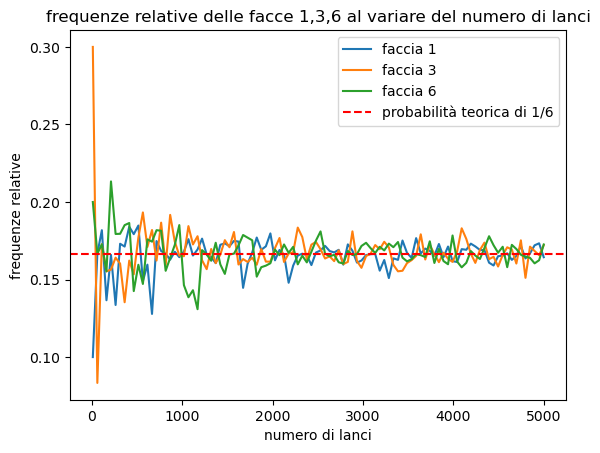

In [79]:
a = np.linspace(10, 5000, 100, dtype=int)
# print(a)

res = [lancia(n) for n in a]
# print(res)

def frequenze(lanci):
    conteggi = np.bincount(lanci, minlength=7)[1:] #funzione che calcola quante volte un inetro esce in un array: da 0 a minlength: tolgo la prima possizione perchè la faccia che vale 0 non esiste
    return conteggi / len(lanci)

freq = np.array([frequenze(n) for n in res])
#print(freq)

import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(freq, columns=["1","2","3","4","5","6"], index=a)
df


plt.plot(df.index, df["1"], label="faccia 1")
plt.plot(df.index, df["3"], label = "faccia 3")
plt.plot(df.index, df["6"], label = "faccia 6")
plt.axhline(1/6, 0, 5000, label = "probabilità teorica di 1/6", linestyle="--", color="r")
plt.legend()
plt.title("frequenze relative delle facce 1,3,6 al variare del numero di lanci")
plt.xlabel("numero di lanci")
plt.ylabel("frequenze relative")

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 7 x 7, con valori estratti da una distribuzione normale con media = 0, ed std = 5.

2. Per ogni riga, identifica il valore più lontano da zero (cioè con valore assoluto massimo). Crea un array con questi 7 valori (uno per riga).

3. Calcola quante di queste righe hanno il valore più lontano da zero positivo?

In [ ]:
np.random.seed(0)
numeri = np.random.normal(0, 5, 49)
matrix = np.array(numeri).reshape(7,7)


matrix_abs = abs(matrix)
index_max=[]

for i in range(7):
    index_max.append(matrix_abs[i].argmax())

values_max = np.array(matrix_abs[[0,1,2,3,4,5,6], index_max])


print(sum(matrix[[0,1,2,3,4,5,6], index_max]>0))

4


## Esercizio 4 

Utilizza il dataset cereal.csv.

Contiene dati nutrizionali (proteine, fibre, calorie, zuccheri, ecc.) per circa 70 cereali.


1.  Aggiungi una colonna chiamata `nutri_score`, definita come:
$$
\texttt{nutri\_score} = \frac{\texttt{protein} + \texttt{fiber}}{\texttt{calories}}
$$

Indica quanti nutrienti positivi ci sono per ogni caloria: più è alto, più il cereale è "nutriente a parità di energia.

2. Trova i **5 cereali con il `nutri_score` più alto** e stampali con `name` e `nutri_score`.

3. Filtra i cereali che soddisfano entrambi i criteri:

   - meno di 120 calorie  
   - più di 2 grammi di fibra 


4. **Crea un grafico a barre** dei **10 cereali con il `nutri_score` più alto**, usando `name` sull’asse x.

5. Crea uno **scatter plot** (grafico a punti) che visualizzi:

   - `calories` sull’asse x  
   - `nutri_score` sull’asse y
   - `protein` nel colore dei punti


In [139]:
df = pd.read_csv('cereal.csv', sep=";")
df.head()
df.dropna()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193


In [142]:
#aggiungi una colonna chiamata nutri_score definita come (protein+fiber)/calories
df['nutri_score']=(df['protein']+ df['fiber'])/df['calories']
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,nutri_score
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973,0.200000
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679,0.041667
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505,0.185714
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912,0.360000
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843,0.027273


In [ ]:
valori = df['nutri_score'].nlargest(5).values
indici = df['nutri_score'].nlargest(5).index
nomi = list(df['name'][indici]) #se la lascio come pd serie dopo per accedere agli elementi dovevo usare .iloc[1]

valori, indici, nomi

for i in range(5):
    print("{}: {}, {}".format(i, nomi[i], valori[i]))


0: All-Bran with Extra Fiber, 0.36
1: 100% Bran, 0.2
2: All-Bran, 0.18571428571428572
3: Bran Flakes, 0.08888888888888889
4: Shredded Wheat 'n'Bran, 0.07777777777777778


In [ ]:
# 3. Filtra i cereali che soddisfano entrambi i criteri:
#    - meno di 120 calorie  
#    - più di 2 grammi di fibra 

df[(df['calories']<120) | (df['fiber']>2)] #oppure df[(df.calories<120) | (df.fiber>2)]

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating,nutri_score
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973,0.200000
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505,0.185714
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912,0.360000
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843,0.027273
5,Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1.0,0.75,29.509541,0.031818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,Triples,G,C,110,2,1,250,0.0,21.0,3,60,25,3,1.0,0.75,39.106174,0.018182
73,Trix,G,C,110,1,1,140,0.0,13.0,12,25,25,2,1.0,1.00,27.753301,0.009091
74,Wheat Chex,R,C,100,3,1,230,3.0,17.0,3,115,25,1,1.0,0.67,49.787445,0.060000
75,Wheaties,G,C,100,3,1,200,3.0,17.0,3,110,25,1,1.0,1.00,51.592193,0.060000


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'All-Bran with Extra Fiber'),
  Text(1, 0, '100% Bran'),
  Text(2, 0, 'All-Bran'),
  Text(3, 0, 'Bran Flakes'),
  Text(4, 0, "Shredded Wheat 'n'Bran"),
  Text(5, 0, 'Quaker Oatmeal'),
  Text(6, 0, 'Post Nat. Raisin Bran'),
  Text(7, 0, 'Cheerios'),
  Text(8, 0, 'Bran Chex'),
  Text(9, 0, 'Fruit & Fibre Dates, Walnuts, and Oats')])

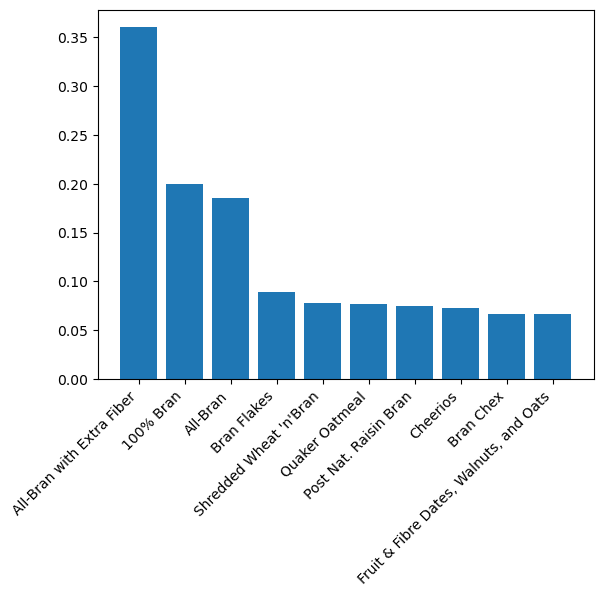

In [166]:
#4. **Crea un grafico a barre** dei **10 cereali con il `nutri_score` più alto**, usando `name` sull’asse x.

data = df['nutri_score'].nlargest(10).values
idx_data = df['nutri_score'].nlargest(10).index
names = list(df['name'][idx_data])

plt.bar(names, data)
plt.xticks(rotation=45, ha='right')



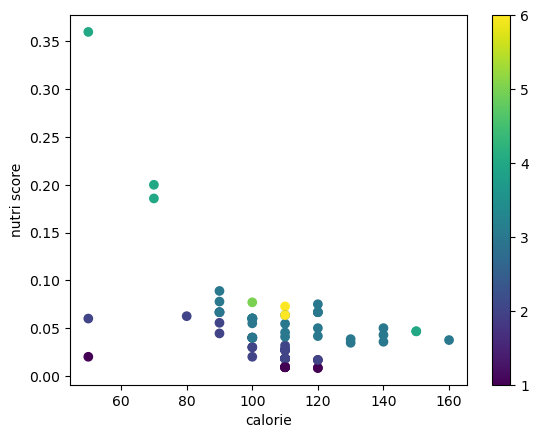

In [ ]:
# 5. Crea uno **scatter plot** (grafico a punti) che visualizzi:
#    - `calories` sull’asse x  
#    - `nutri_score` sull’asse y
#    - `protein` nel colore dei punti

plt.scatter(x=df.calories, y=df.nutri_score, c=df.protein, marker="o")
plt.xlabel("calorie")
plt.ylabel("nutri score")
plt.colorbar() 

## Esercizio 5 

Utilizza il dataset `imdb_top_1000.csv`, che contiene informazioni su 1000 film recensiti su IMDB.

1. Quanti **valori mancanti** ci sono per colonna? Elimina le righe con i valori mancanti.

2. Elimina la colonna `Overview`. Aggiungi una colonna (`main_genre`) con solo il primo genere della colonna `genre`. Quali sono i 5 generi più frequenti?

3. Che attore/attrice è stato/a più volte la `Star1` e quello/a che ha fatto più film.

4. Calcola l'IMDB_rating medio e il Gross medio di ogni genere. Fai uno scatter plot dell'IMDB_rating medio e il Gross medio di ogni genere. Riesci a mettere anche l'ettichetta del genere?

5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).




In [205]:
#1. Quanti **valori mancanti** ci sono per colonna? Elimina le righe con i valori mancanti.
df = pd.read_csv("imdb_top_1000.csv")
df.head()

print(pd.isna(df).sum()) #numero di na per colonna

df = df.dropna()
print(pd.isna(df).sum()) # non ci sono più na

Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64


In [ ]:
#2. Elimina la colonna `Overview`. Aggiungi una colonna (`main_genre`) con solo il primo genere della colonna `genre`. Quali sono i 5 generi più frequenti?
df = df.drop('Overview', axis=1)
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0


In [239]:
df['main_genre'] = df['Genre'].str.split(',').str[0]

df.head()

print(df['main_genre'].value_counts().nlargest(5))

main_genre
Drama        192
Action       127
Comedy       104
Crime         74
Biography     73
Name: count, dtype: int64


In [ ]:
#3. Che attore/attrice è stato/a più volte la `Star1` e quello/a che ha fatto più film.
print(df['Star1'].value_counts().idxmax()) #Tom Hanks

attori = pd.concat([
    df["Star1"],
    df["Star2"],
    df["Star3"],
    df["Star4"]
])

print(attori.value_counts().idxmax()) #Robert De Niro


Tom Hanks
Robert De Niro


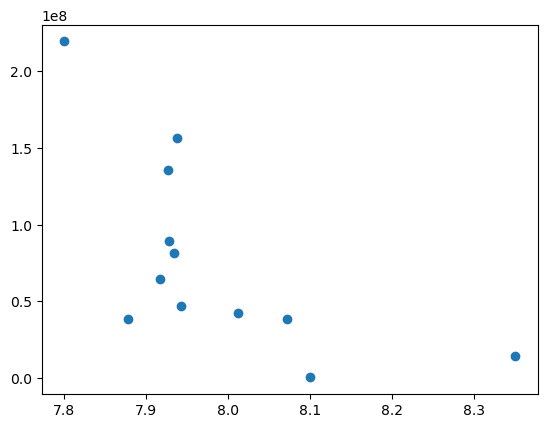

In [264]:
#4. Calcola l'IMDB_rating medio e il Gross medio di ogni genere. Fai uno scatter plot dell'IMDB_rating medio e il Gross medio di ogni genere. Riesci a mettere anche l'ettichetta del genere?

x = df.groupby('main_genre')['IMDB_Rating'].mean()
y = df.groupby('main_genre')['Gross'].mean()


plt.scatter(x=x, y=y)

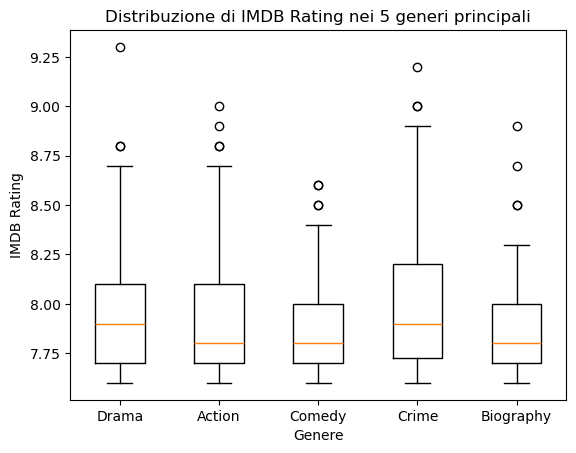

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x197c9b5d670>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x197c9b3da30>,
 'cmins': <matplotlib.collections.LineCollection at 0x197c9b6fe90>,
 'cbars': <matplotlib.collections.LineCollection at 0x197c9b2df10>}

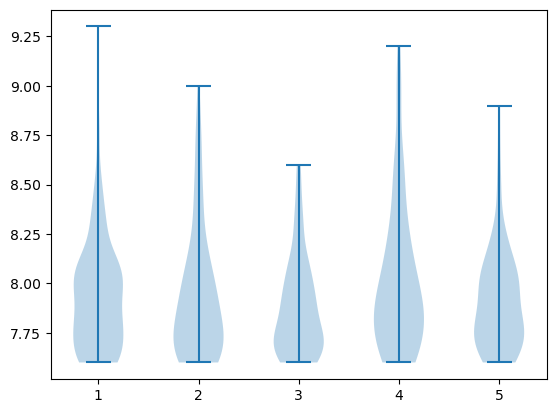

In [273]:
#5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).
top5 = df["main_genre"].value_counts().nlargest(5).index
dati = [df[df["main_genre"] == g]["IMDB_Rating"] for g in top5]

plt.boxplot(dati, tick_labels=top5)
plt.xlabel("Genere")
plt.ylabel("IMDB Rating")
plt.title("Distribuzione di IMDB Rating nei 5 generi principali")
plt.show()

plt.violinplot(dati)

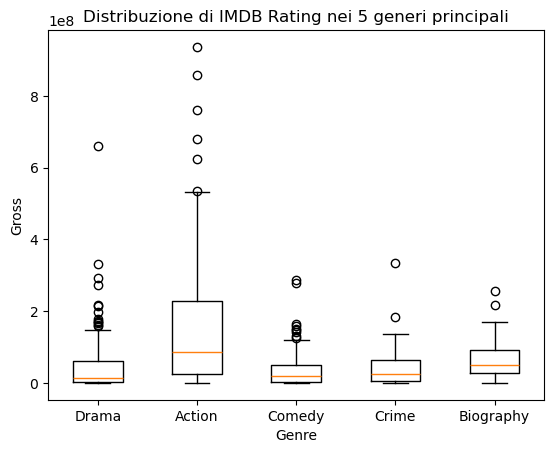

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x197cb90d4c0>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x197c9b43b60>,
 'cmins': <matplotlib.collections.LineCollection at 0x197cb938e30>,
 'cbars': <matplotlib.collections.LineCollection at 0x197c7ccd5b0>}

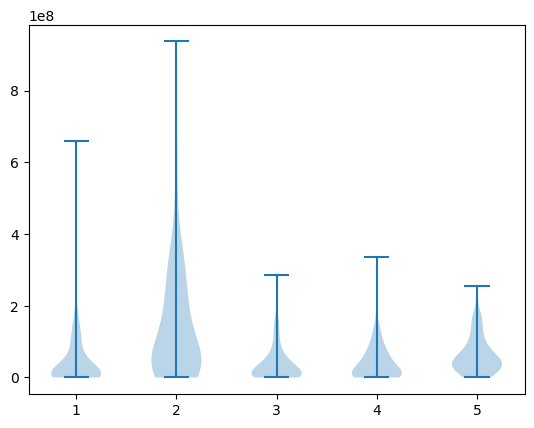

In [274]:
#5. Visualizza la distribuzione del IMDB_rating  e la distribuzione del `Gross` dei primi 5 main_genre. (Hint fai due violin plot).
top5 = df["main_genre"].value_counts().nlargest(5).index
dati = [df[df["main_genre"] == g]["Gross"] for g in top5]

plt.boxplot(dati, tick_labels=top5)
plt.xlabel("Genre")
plt.ylabel("Gross")
plt.title("Distribuzione di IMDB Rating nei 5 generi principali")
plt.show()

plt.violinplot(dati)

## Esercizio 6

Considera i seguenti dati, che :

`x = np.linspace(0, 10, 100)`  
`y = -3.5 * x + 2 + np.random.normal(0, 10, 100)`

Cerca di riprodurre la retta fittando i parametri della funzione y = ax + b.

1. Stima i parametri della retta.
2. Calcola l’intervallo di confidenza al 95% dei parametri a e b.
N.B il secondo output del metodo curve_fit è proprio la matrice di covarianza: `params, cov = curve_fit(retta, x, y)`. 
L'**errore standard** di ciascun parametro si calcola come:

$$
\text{errore\_standard}_i = \sqrt{\text{cov}(i, i)}
$$

dove $\text{cov}(i, i)$ è l'elemento diagonale $i$-esimo della **matrice di covarianza**.

L’**intervallo di confidenza al 95%** si approssima con:

$$
\text{parametro}_i \pm 1.96 \times \text{errore\_standard}_i
$$
3. Plotta i punti originali e la retta ottenuta con anche l'intervallo di confidenza

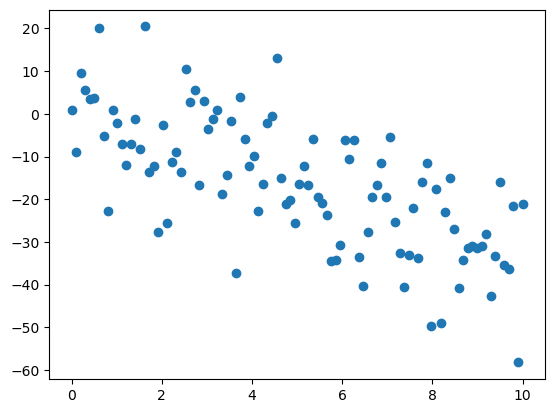

In [281]:
import scipy as sp
x = np.linspace(0, 10, 100)
y = -3.5 * x + 2 + np.random.normal(0, 10, 100)

plt.scatter(x,y)

In [290]:
def lineare(x, m, q):
    return m*x+q

popt , cov = sp.optimize.curve_fit(lineare, x,y)
q = popt[1]
m = popt[0]

In [ ]:
from math import sqrt
errore_standard = [sqrt(cov[i,i]) for i in range(2)]

m_high = m+errore_standard[0]*1,96
m_low = m-errore_standard[0]*1,96

q_high = m+errore_standard[1]*1,96
q_low = m-errore_standard[1]*1,96

(np.float64(-3.284382348269649), 96)


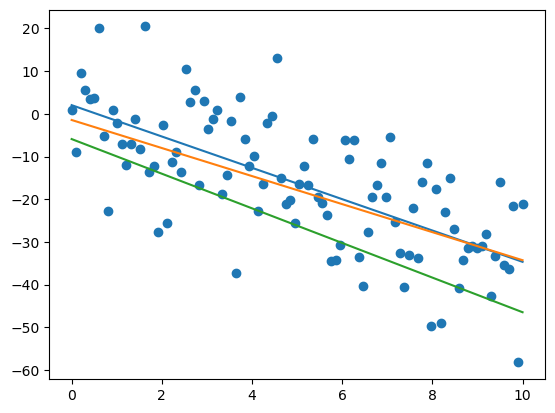

In [311]:
plt.scatter(x,y)
plt.plot(x, lineare(x,m,q))
plt.plot(x, lineare(x, m_high[0], q_high[0]))
plt.plot(x,lineare(x, m_low[0], q_low[0]))